# 02 초기 특징 추출과 전처리

원본 MAT에서 cycle100까지의 관측을 읽어 ΔQ·RMS와 추가 후보를 계산합니다. 정답은 원본 `cycle_life`이며, 결측 수명을 채우지 않습니다. 최종 입력은 ΔQ 로그분산·RMS·ΔQ 5% 분위수·ΔQ 평균입니다. 전체 열화 곡선은 EDA 설명에만 사용합니다.


In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Markdown, Image, Code
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/pipeline.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.pipeline import load_config, choose_raw_dir
CONFIG = load_config(ROOT / 'config/model.json')
RAW_DIR = choose_raw_dir(ROOT, CONFIG)
print('프로젝트:', ROOT)
print('원본 폴더:', RAW_DIR)


프로젝트: .
원본 폴더: ../archive


## 1 기존 원본과 필요한 셀 관측 읽기

파일 확인: 지정한 날짜의 B1/B2/B3가 맞는지 봅니다. 셀 ID 확인: 각 특징과 수명이 같은 셀인지 봅니다. B1c20은 배치1 파일 내0부터 시작하는 인덱스20의 기록입니다.


In [2]:
from src.preprocess import read_early_cells
from src.features import delta_q_log_variance, rms_current, relative_capacity_mad, extract_features
example = next(read_early_cells(RAW_DIR, CONFIG['batches']))
print('예시 셀:', example.cell_key, '정답 cycle_life:', example.cycle_life)
print('실제 사이클:', example.cycle[0], '부터', example.cycle[-1])
print('공통 전압점:', len(example.voltage))


예시 셀: B1c0 정답 cycle_life: 1190.0
실제 사이클: 1.0 부터 100.0
공통 전압점: 1000


## 2 ΔQ 로그 분산

$$\Delta Q(V)=Q_{100}(V)-Q_{10}(V),\quad x_1=\log_{10}(\mathrm{Var}(\Delta Q(V);ddof=1))$$

초기 전압별 용량 변화 폭을 요약합니다. 모든 배치에서 수명과 강한 음의 관계가 있어 기본 입력입니다. 같은 전압축에서 비교하며 첫 빈 사이클 때문에 번호를 당기지 않습니다.


ΔQ 표본분산: 9.673273538309652e-06 로그분산: -5.0144265311867695


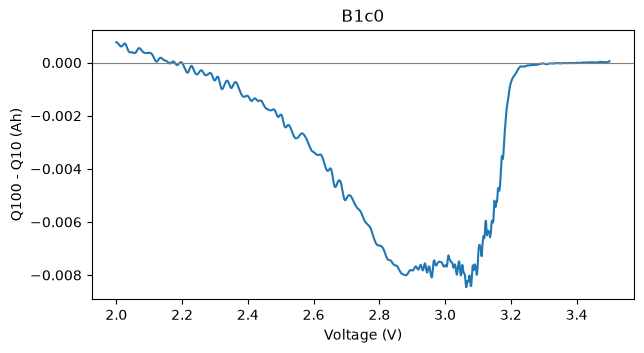

In [3]:
import numpy as np
import matplotlib.pyplot as plt
delta = example.q100 - example.q10
dq_feature = delta_q_log_variance(example, CONFIG['quality']['curve_min_ptp_ah'])
print('ΔQ 표본분산:', np.var(delta, ddof=1), '로그분산:', dq_feature)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(example.voltage, delta)
ax.axhline(0, color='gray', linewidth=.8)
ax.set(xlabel='Voltage (V)', ylabel='Q100 - Q10 (Ah)', title=example.cell_key)
plt.show()


## 3 추가 ΔQ 특징: 5% 분위수와 평균

`dq100_10_q05_ah`는 큰 음의 변화를 한 점의 최솟값보다 덜 민감하게 요약합니다. `dq100_10_mean_ah`는 곡선 전체의 부호 있는 이동량을 보완합니다. 둘 다 새로운 센서 없이 기존 ΔQ에서 계산하며 단위는Ah입니다.


In [4]:
print('ΔQ 5% 분위수 (Ah):', np.quantile(delta, 0.05, method='linear'))
print('ΔQ 평균 (Ah):', np.mean(delta))


ΔQ 5% 분위수 (Ah): -0.007867310949289313
ΔQ 평균 (Ah): -0.0028734152246919164


## 4 Cycle10 시간 가중 RMS 전류

$$x_2=\sqrt{\frac{\sum_i\Delta t_i(C_{i,0}^2+C_{i,0}C_{i,1}+C_{i,1}^2)/3}{\sum_i\Delta t_i}}$$

첫 방전 시작 전의 유효 충전 구간만 사용합니다. 양끝 전류>0.1C, 유한 전류·시간, dt>0인 구간입니다. 시간 단위는분이며 원본 전류값을 사용해 cycle10 한 회의 전류 강도와 지속 시간 비중을 표현합니다.


In [5]:
import inspect
rms_feature, rms_qc = rms_current(example.current10, example.time10)
print('원본 전류 RMS:', rms_feature)
display(pd.Series(rms_qc))
# 수식이 실제 코드에서 어떻게 계산되는지 보여줍니다.
display(Code(inspect.getsource(rms_current), language='python'))


원본 전류 RMS: 2.596873347373412


rms_active_intervals            556.000000
rms_active_minutes               27.004617
rms_nonfinite_intervals           0.000000
rms_nonpositive_dt_intervals      0.000000
dtype: float64

def rms_current(current: np.ndarray, time: np.ndarray) -> tuple[float, dict]:
    current, time = np.asarray(current, float), np.asarray(time, float)
    if len(current) != len(time) or len(current) < 3:
        raise ValueError("cycle10 전류와 시간 길이가 맞지 않거나 너무 짧습니다.")
    discharge = np.flatnonzero(np.isfinite(current) & (current < -0.5))
    if not len(discharge):
        raise ValueError("cycle10에서 첫 방전 시작점을 찾지 못했습니다.")
    end = int(discharge[0])
    a, b = current[:max(0, end - 1)], current[1:end]
    left, right = time[:max(0, end - 1)], time[1:end]
    dt = right - left
    finite = np.isfinite(a) & np.isfinite(b) & np.isfinite(left) & np.isfinite(right)
    active = finite & (a > 0.1) & (b > 0.1) & (dt > 0)
    if int(active.sum()) < 2:
        raise ValueError("cycle10에 유효 충전 구간이2개 미만입니다.")
    av, bv, duration = a[active], b[active], dt[active]
    second = np.dot(duration, (av * av + av * bv + bv * bv) / 3) / duration.sum()
    qc = {
        "rms_active_intervals": int(active.sum()),
        "rms_active_minutes": float(duration.sum()),
        "rms_nonfinite_intervals": int((~finite).sum()),
        "rms_nonpositive_dt_intervals": int((np.isfinite(dt) & (dt <= 0)).sum()),
    }
    return float(np.sqrt(second)), qc

## 5 상대 용량 MAD: 비교 후 미선정

초기 Qd2~100의 MAD를 유효 Qd2~10 중앙값으로 나눕니다. 극단값에 덜 민감한 변동 요약이지만 최초 CV에서 추가 예측 가치가 확인되지 않아 최종 입력에서는 제외했습니다. 원래 비교를 재현하기 위해 계산값을 보관합니다.


In [6]:
mad_feature, mad_qc = relative_capacity_mad(example, CONFIG['quality']['qd_max_ah'], CONFIG['quality']['reference_min_valid'])
print('상대 MAD:', mad_feature)
display(pd.Series(mad_qc))
display(Code(inspect.getsource(relative_capacity_mad), language='python'))


상대 MAD: 0.00028055766144570606


mad_qd_valid_n    99.000000
q_ref_ah           1.073576
q_ref_valid_n      9.000000
dtype: float64

def relative_capacity_mad(cell: EarlyCell, max_qd: float = 1.65, min_reference: int = 5) -> tuple[float, dict]:
    valid = np.isfinite(cell.qd) & (cell.qd > 0) & (cell.qd <= max_qd)
    values = cell.qd[valid & (cell.cycle >= 2) & (cell.cycle <= 100)]
    reference = cell.qd[valid & (cell.cycle >= 2) & (cell.cycle <= 10)]
    if len(values) < 1 or len(reference) < min_reference:
        raise ValueError(f"{cell.cell_key}: MAD 또는 기준 용량의 유효 관측이 부족합니다.")
    q_ref = float(np.median(reference))
    mad = float(np.median(np.abs(values - np.median(values))) / q_ref)
    return mad, {"mad_qd_valid_n": int(len(values)), "q_ref_ah": q_ref,
                 "q_ref_valid_n": int(len(reference))}

## 6 셀별 특징과 정답 연결

139개 셀에서 동일한 식으로 계산합니다. CSV에는 최종 입력4개, 기존 MAD, IR을 제외한 순위 후보9개와 품질 정보를 보관합니다. 모든 후보는 cycle100까지 얻을 수 있습니다. 후보 전체를 최종 모델에 넣지는 않습니다. ID·배치·정책은 분할과 연결에만 사용합니다.


In [7]:
import time
from src.features import STACKING_FEATURES, RANKING_CANDIDATES
start = time.perf_counter()
frame, source_files = extract_features(RAW_DIR, CONFIG)
extraction_seconds = time.perf_counter() - start
display(frame[['cell_key', 'batch', 'policy', *STACKING_FEATURES, 'cycle_life']].head())
display(frame.groupby('batch').agg(records=('cell_key', 'size'), labeled=('cycle_life', 'count')))
print('최종 입력:', STACKING_FEATURES)
print('학습 중 순위 비교 후보:', RANKING_CANDIDATES)


,cell_key,batch,policy,dq100_10_log_variance,cycle10_rms_c_timeweighted,dq100_10_q05_ah,dq100_10_mean_ah,cycle_life
0,B1c0,B1,3.6C(80%)-3.6C,-5.014427,2.596873,-0.007867,-0.002873,1190.0
1,B1c1,B1,3.6C(80%)-3.6C,-5.013525,2.575319,-0.009778,-0.004100,1179.0
2,B1c2,B1,3.6C(80%)-3.6C,-4.736565,2.572973,-0.013720,-0.004487,1177.0
3,B1c3,B1,4C(80%)-4C,-4.442179,2.742083,-0.018165,-0.007456,1226.0
4,B1c4,B1,4C(80%)-4C,-4.647309,2.767509,-0.013617,-0.005750,1227.0


,records,labeled
batch,,
B1,46,46
B2,47,39
B3,46,44


최종 입력: ['dq100_10_log_variance', 'cycle10_rms_c_timeweighted', 'dq100_10_q05_ah', 'dq100_10_mean_ah']
학습 중 순위 비교 후보: ['capacity_q100_q10_change_relative', 'capacity_theilsen_10_100_relative', 'capacity_theilsen_60_100_relative', 'dq100_10_q05_ah', 'dq100_10_mean_v2p0_2p4_ah', 'dq100_10_mean_ah', 'tavg_theilsen_10_100_degC_per_cycle', 'tavg_median_2_100_degC', 'chargetime_median_2_100_minutes']


## 7 CSV 저장과 특징·수명 관계 도표

원본 MAT를 바꾸지 않고 셀당 한 행의 표를 저장합니다. 다음 노트북은 이 표로 학습합니다. 아래 상관·분포 그림은 EDA이며 예측 정확도와 다릅니다.


저장: ./data/processed/cell_features.csv


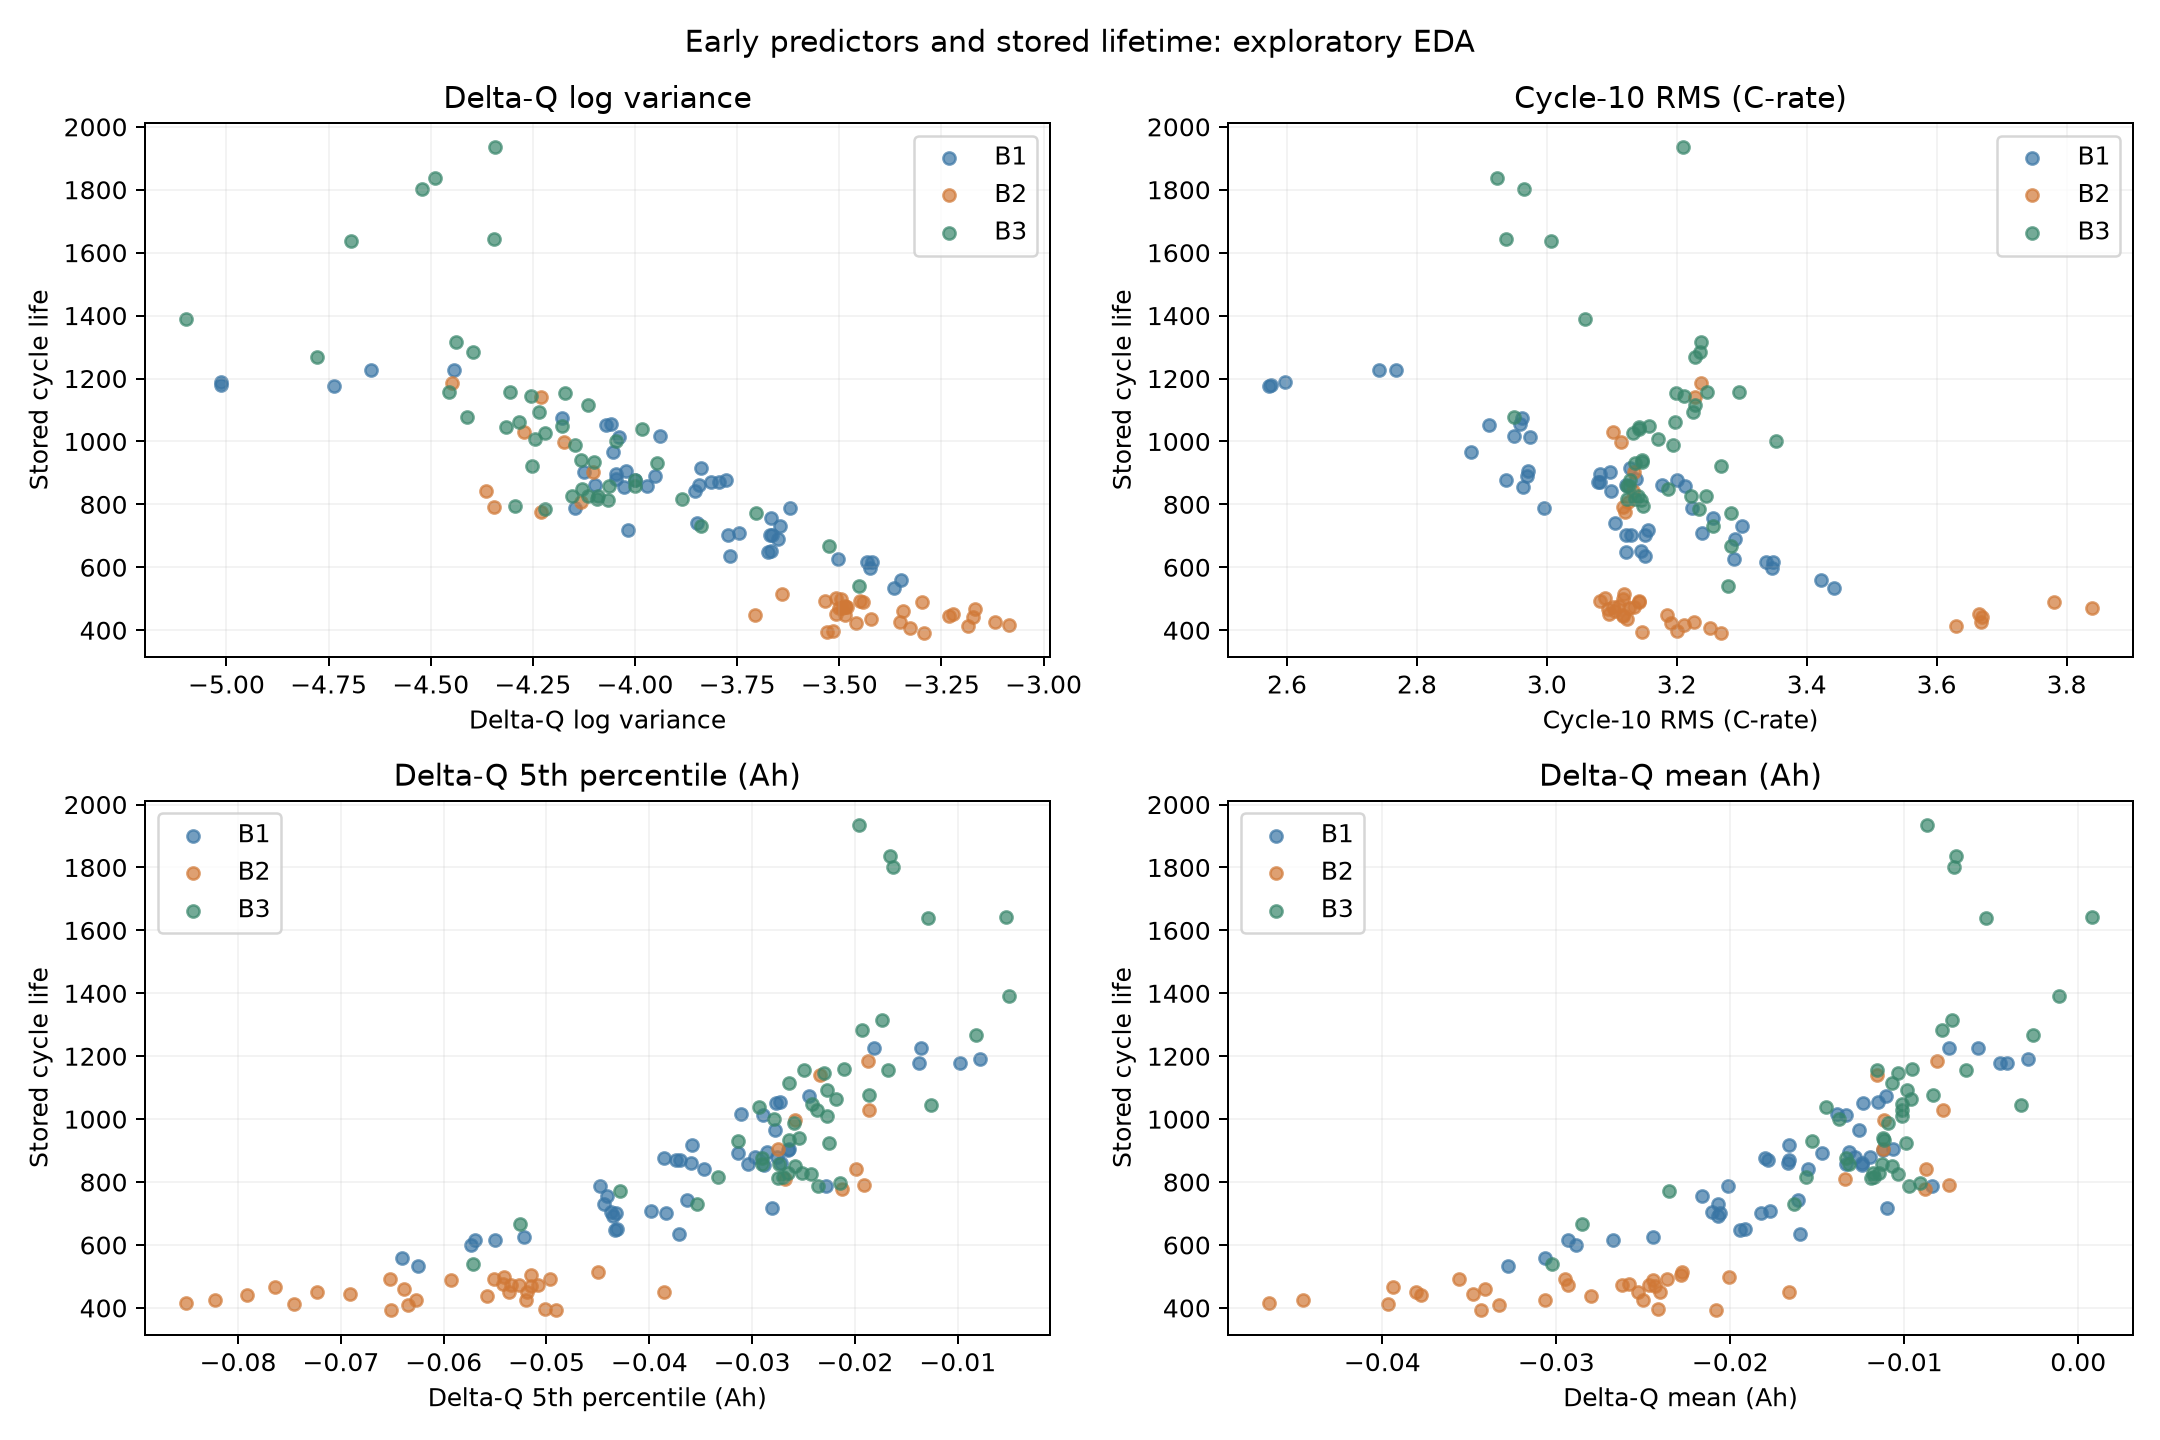

,scope,feature,n,Pearson_r,Spearman_rho
0,ALL,dq100_10_log_variance,129,-0.850609,-0.892074
1,ALL,cycle10_rms_c_timeweighted,129,-0.431664,-0.322946
2,ALL,dq100_10_q05_ah,129,0.827376,0.884091
3,ALL,dq100_10_mean_ah,129,0.797377,0.869274
4,B1,dq100_10_log_variance,46,-0.886123,-0.871161
5,B1,cycle10_rms_c_timeweighted,46,-0.890702,-0.855804
6,B1,dq100_10_q05_ah,46,0.885424,0.856359
7,B1,dq100_10_mean_ah,46,0.853810,0.828112
8,B2,dq100_10_log_variance,39,-0.901883,-0.708979
9,B2,cycle10_rms_c_timeweighted,39,-0.207033,-0.381516


In [8]:
from src.pipeline import save_features
from src.report import write_feature_diagnostics
csv_path = save_features(frame, source_files, ROOT, extraction_seconds)
write_feature_diagnostics(frame, ROOT / 'results/feature_diagnostics')
print('저장:', csv_path)
display(Image(filename=str(ROOT / 'results/feature_diagnostics/selected_features_vs_life.png')))
display(pd.read_csv(ROOT / 'results/feature_diagnostics/feature_life_correlations.csv'))


## 8 모델 학습으로 넘길 자료

B1 학습35개에서 IR을 제외한 후보를 실제 수명과의 절대 Pearson 상관으로 순위화해2개를 선택했습니다. 전체 학습 부분의 최종 선택은 ΔQ 5% 분위수와 평균입니다. CV에서는 매 학습 부분 안에서 후보 순위·표준화·XGBoost 조정값을 다시 선택합니다. 따라서 CV 과정에서 선택되는 후보가 최종2개와 다를 수 있습니다.

추가2개는 상관이 매우 높아 독립 신호라고 주장하지 않습니다. Ridge 규제와 반복 그룹 CV로 실제 예측 개선을 확인했습니다. Knee·후기 기울기·최종 용량·전체 관측 길이는 입력에서 제외합니다.
